In [1]:
import gensim.downloader as api

# Load pre-trained Word2Vec model
model = api.load("word2vec-google-news-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [2]:
model['apple']  # Get the vector for the word "apple"

array([-0.06445312, -0.16015625, -0.01208496,  0.13476562, -0.22949219,
        0.16210938,  0.3046875 , -0.1796875 , -0.12109375,  0.25390625,
       -0.01428223, -0.06396484, -0.08056641, -0.05688477, -0.19628906,
        0.2890625 , -0.05151367,  0.14257812, -0.10498047, -0.04736328,
       -0.34765625,  0.35742188,  0.265625  ,  0.00188446, -0.01586914,
        0.00195312, -0.35546875,  0.22167969,  0.05761719,  0.15917969,
        0.08691406, -0.0267334 , -0.04785156,  0.23925781, -0.05981445,
        0.0378418 ,  0.17382812, -0.41796875,  0.2890625 ,  0.32617188,
        0.02429199, -0.01647949, -0.06494141, -0.08886719,  0.07666016,
       -0.15136719,  0.05249023, -0.04199219, -0.05419922,  0.00108337,
       -0.20117188,  0.12304688,  0.09228516,  0.10449219, -0.00408936,
       -0.04199219,  0.01409912, -0.02111816, -0.13476562, -0.24316406,
        0.16015625, -0.06689453, -0.08984375, -0.07177734, -0.00595093,
       -0.00482178, -0.00089264, -0.30664062, -0.0625    ,  0.07

In [3]:
len(model['apple'])  # Check the dimensionality of the vector

300

In [4]:
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

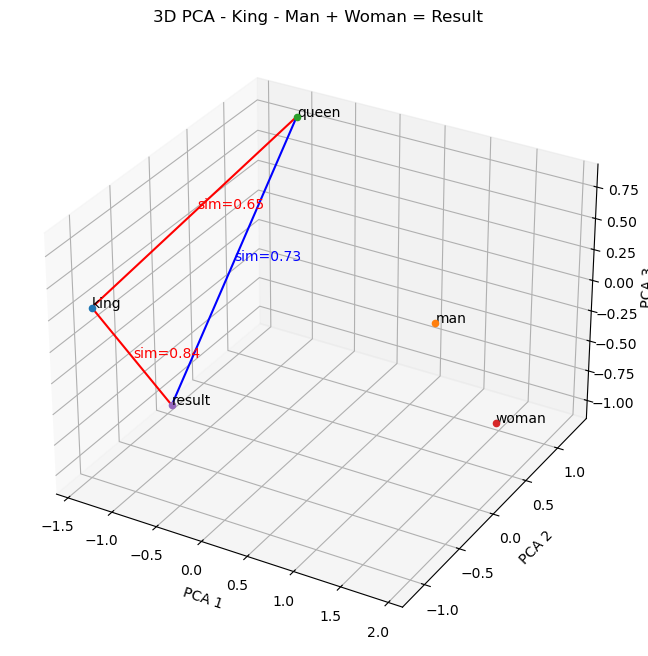

In [5]:
v_king = model['king']
v_man = model['man'] # Corrected: should be model['man']
v_woman = model['woman'] # Corrected: should be model['woman']
v_queen = model['queen'] # Corrected: should be model['queen']
v_result = v_king - v_man + v_woman

words_to_plot = ['king', 'man', 'queen', 'woman', 'result']
vectors_to_plot = [v_king, v_man, v_queen, v_woman, v_result]

pca = PCA(n_components = 3)
reduced = pca.fit_transform(vectors_to_plot) # Reducción de dimensionalidad
coords = {word: reduced[i] for i, word in enumerate(words_to_plot)}

def cos(a, b):
  return cosine_similarity([a], [b])[0, 0]

fig = plt.figure(figsize = (10, 8))
ax = fig.add_subplot(111, projection='3d')

for word, vec in coords.items():
  ax.scatter(vec[0], vec[1], vec[2])
  ax.text(vec[0], vec[1], vec[2], word)

result = coords['result']
king = coords['king']
queen = coords['queen']

# Result <-> King
ax.plot([result[0], king[0]], [result[1], king[1]], [result[2], king[2]], color='red')
mid_rk = (result + king) / 2.0
ax.text(mid_rk[0], mid_rk[1], mid_rk[2],
        f"sim={cos(v_result, v_king):.2f}", color='red')

# King <-> Queen
ax.plot([king[0], queen[0]], [king[1], queen[1]], [king[2], queen[2]], color='red')
mid_kq = (king + queen) / 2.0 # Corrected: renamed to mid_kq for clarity
ax.text(mid_kq[0], mid_kq[1], mid_kq[2], # Corrected: used mid_kq
        f"sim={cos(v_king, v_queen):.2f}", color='red')

# Result <-> Queen
ax.plot([result[0], queen[0]], [result[1], queen[1]], [result[2], queen[2]], color='blue')
mid_rq = (result + queen) / 2.0 # Corrected: renamed to mid_rq for clarity
ax.text(mid_rq[0], mid_rq[1], mid_rq[2], # Corrected: used mid_rq
        f"sim={cos(v_result, v_queen):.2f}", color='blue')

ax.set_title("3D PCA - King - Man + Woman = Result")
ax.set_xlabel("PCA 1"); ax.set_ylabel("PCA 2"); ax.set_zlabel("PCA 3")
plt.show()

In [6]:
similar_words = model.most_similar(positive=[v_result], topn=10)

print("Top 10 palabras más similares a la operación 'king - man + woman':")
for word, similarity in similar_words:
  print(f"{word}: {similarity:.4f}")

Top 10 palabras más similares a la operación 'king - man + woman':
king: 0.8449
queen: 0.7301
monarch: 0.6455
princess: 0.6156
crown_prince: 0.5819
prince: 0.5777
kings: 0.5614
sultan: 0.5377
Queen_Consort: 0.5344
queens: 0.5290


In [7]:
similar_words = model.most_similar(positive=[v_queen], topn=10)

print("Top 10 palabras más similares a la operación 'queen':")
for word, similarity in similar_words:
  print(f"{word}: {similarity:.4f}")

Top 10 palabras más similares a la operación 'queen':
queen: 1.0000
queens: 0.7399
princess: 0.7071
king: 0.6511
monarch: 0.6384
very_pampered_McElhatton: 0.6357
Queen: 0.6163
NYC_anglophiles_aflutter: 0.6061
Queen_Consort: 0.5924
princesses: 0.5908


In [8]:
similar_words = model.most_similar(positive=[v_king], topn=10)

print("Top 10 palabras más similares a la operación 'king':")
for word, similarity in similar_words:
  print(f"{word}: {similarity:.4f}")

Top 10 palabras más similares a la operación 'king':
king: 1.0000
kings: 0.7138
queen: 0.6511
monarch: 0.6413
crown_prince: 0.6204
prince: 0.6160
sultan: 0.5865
ruler: 0.5798
princes: 0.5647
Prince_Paras: 0.5433
